# 🦜 Colombian Bird Song — Audio Pre-Processing Pipeline

This notebook prepares the audio dataset for model training. It fetches bird recording metadata directly from [Xeno-Canto](https://xeno-canto.org), filters recordings/species using your project rules, downloads MP3 files to Google Drive, and prepares the next steps for mel-spectrogram conversion.

---

## Pipeline Overview

| Step | Description | Status |
|------|-------------|--------|
| 1 | Setup & Authentication | ✅ |
| 2 | Mount Drive & Configure Paths | ✅ |
| 3 | Fetch Metadata from Xeno-Canto | ✅ |
| 4 | Filter Species & Recordings | ✅ |
| 5 | Download Recordings to Drive | ✅ |
| 6 | Chunk MP3s → WAV export | 🔜 |
| 7 | Diagnostic visualization + Mel-spectrograms | 🔜 |
| 7.5 | Chunk audition (waveform + spectrogram + playback) | 🔜 |
| 8 | Export tensors for training | 🔜 |
| 9 | Fold split materialization (5 × train/val pairs) | 🔜 |
| 10 | Archive & save ready-to-train splits | 🔜 |


## Step 1 — Setup & Authentication

Install required packages and enter your Xeno-Canto API key securely in the runtime.

Generate the key from your Xeno-Canto account page: https://xeno-canto.org/account/api

The notebook cannot access your account or generate the key for you.

In [1]:
# Install required packages
%pip install requests

print("Enter your Xeno-Canto API key.")
print("Generate it from your account page: https://xeno-canto.org/account/api")
print("This notebook cannot access your account or create a key for you.")
XC_API_KEY = input("XC_API_KEY: ").strip()

if not XC_API_KEY:
    print("Warning: no API key provided. Metadata fetching will fail until one is set.")

Enter your Xeno-Canto API key.
Generate it from your account page: https://xeno-canto.org/account/api
This notebook cannot access your account or create a key for you.


## Step 2 — Configure Storage & Paths

Set `USE_DRIVE = True` to persist all output to Google Drive (survives session restarts).  
Set `USE_DRIVE = False` to write everything to the Colab local disk (`/content/`) — faster I/O, but cleared when the session ends.

When `USE_DRIVE = True`, Google Drive is mounted automatically.

| Path variable | Drive (`True`) | Local disk (`False`) |
|---|---|---|
| `OUTPUT_DIR` | `MyDrive/bird_songs/` | `/content/bird_songs/` |
| `PROCESSED_DIR` | `MyDrive/processed_audio/` | `/content/processed_audio/` |
| `TENSORS_DIR` | `MyDrive/bird_tensors/` | `/content/bird_tensors/` |

Metadata files (`/content/data/`) are always stored on the local runtime disk and are cleared each session.


In [2]:
from pathlib import Path

# ── Storage target ────────────────────────────────────────────────────────
# True  → persist output to Google Drive (survives session restarts)
# False → store everything on Colab local disk (/content/); cleared each session
USE_DRIVE = False

DOWNLOAD_FOLDER_NAME = "bird_songs"

# ── Runtime metadata (always local, cleared each session) ─────────────────
TEMP_DATA_DIR  = Path("/content/data")
RAW_DIR        = TEMP_DATA_DIR / "raw"
RAW_JSON_PATH  = TEMP_DATA_DIR / "colombia_birds_by_species.json"
FILTERED_JSON_PATH = TEMP_DATA_DIR / "colombia_birds_filtered.json"

RAW_DIR.mkdir(parents=True, exist_ok=True)

# ── Output paths (Drive or local based on USE_DRIVE) ──────────────────────
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_BASE = Path("/content/drive/MyDrive")
else:
    OUTPUT_BASE = Path("/content")

OUTPUT_DIR    = OUTPUT_BASE / DOWNLOAD_FOLDER_NAME
PROCESSED_DIR = OUTPUT_BASE / "processed_audio"
TENSORS_DIR   = OUTPUT_BASE / "bird_tensors"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Storage mode  : {'Google Drive' if USE_DRIVE else 'Colab local disk'}")
print(f"Metadata dir  : {TEMP_DATA_DIR}")
print(f"Raw page dir  : {RAW_DIR}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Processed dir : {PROCESSED_DIR}")
print(f"Tensors dir   : {TENSORS_DIR}")


Storage mode  : Colab local disk
Metadata dir  : /content/data
Raw page dir  : /content/data/raw
Output dir    : /content/bird_songs
Processed dir : /content/processed_audio
Tensors dir   : /content/bird_tensors


## ⚙️ Run Configuration

Set `CLEAN_RUN = True` to delete all data produced by previous runs before starting.  
Set `CLEAN_RUN = False` to keep existing data and resume from where the last run left off.

Folders removed when `CLEAN_RUN = True`:
- `bird_songs/` — downloaded MP3s and the persisted filtered metadata JSON
- `processed_audio/` — 3-second WAV chunks
- `bird_tensors/` — compressed `.npz` tensors and `tensor_index.json`

The target location of these folders depends on the `USE_DRIVE` flag set in Step 2.

> ⚠️ This cell must be run **after** Step 2 (paths must be defined).


In [3]:
import shutil

# ── Set to True to wipe all output from previous runs ────────────────────
CLEAN_RUN = False

CLEAN_TARGETS = [
    (OUTPUT_DIR,    "bird_songs (MP3s + metadata)"),
    (PROCESSED_DIR, "processed_audio (WAV chunks)"),
    (TENSORS_DIR,   "bird_tensors (NPZ tensors)"),
]

if CLEAN_RUN:
    for target_path, label in CLEAN_TARGETS:
        if target_path.exists():
            shutil.rmtree(target_path)
            target_path.mkdir(parents=True, exist_ok=True)
            print(f"Cleared : {label} ({target_path})")
        else:
            print(f"Not found (nothing to clear): {label}")
    print("Clean run ready. All previous output has been removed.")
else:
    found = [label for path, label in CLEAN_TARGETS if path.exists()]
    if found:
        print("Resuming with existing data:")
        for label in found:
            print(f"  ✓ {label}")
    else:
        print("No existing output found. Starting fresh (same as CLEAN_RUN = True).")


Resuming with existing data:
  ✓ bird_songs (MP3s + metadata)


## Step 3 — Fetch Metadata from Xeno-Canto

Fetch all Colombian bird recordings from the Xeno-Canto API v3 (`cnt:colombia grp:birds`), save raw page responses, validate country/group/coordinates, then aggregate results by species.

In [4]:
import json
import requests

BASE_URL = "https://xeno-canto.org/api/3/recordings"
QUERY = "cnt:colombia grp:birds"
PER_PAGE = 500

COL_LAT_MIN, COL_LAT_MAX = -4.5, 13.0
COL_LNG_MIN, COL_LNG_MAX = -82.0, -66.5


def fetch_page(query: str, page: int) -> dict:
    params = {
        "query": query,
        "key": XC_API_KEY,
        "per_page": PER_PAGE,
        "page": page,
    }
    response = requests.get(
        BASE_URL,
        params=params,
        headers={"Accept": "application/json"},
        timeout=30,
    )
    response.raise_for_status()
    return response.json()


def save_raw_page(data: dict, page: int) -> None:
    with open(RAW_DIR / f"page_{page:04d}.json", "w", encoding="utf-8") as fh:
        json.dump(data, fh, ensure_ascii=False, indent=2)


def in_colombia_bbox(lat: str, lon: str) -> bool:
    try:
        flat, flon = float(lat), float(lon)
    except (ValueError, TypeError):
        return True
    return (COL_LAT_MIN <= flat <= COL_LAT_MAX) and (COL_LNG_MIN <= flon <= COL_LNG_MAX)


def validate_colombian_birds(recordings: list[dict]) -> list[dict]:
    validated = []
    for r in recordings:
        if r.get("grp", "").lower() != "birds":
            continue
        if r.get("cnt", "").lower() != "colombia":
            continue
        if not in_colombia_bbox(r.get("lat", ""), r.get("lon", "")):
            continue
        validated.append(r)
    return validated


def group_by_species(recordings: list[dict]) -> dict:
    species_map = {}

    for r in recordings:
        genus = r.get("gen", "").strip()
        epithet = r.get("sp", "").strip()
        key = f"{genus} {epithet}".strip()

        if key not in species_map:
            species_map[key] = {
                "scientific_name": key,
                "genus": genus,
                "species": epithet,
                "subspecies_seen": sorted({r.get("ssp", "").strip()} - {""}),
                "english_name": r.get("en", ""),
                "group": r.get("grp", ""),
                "recording_count": 0,
                "recordings": [],
            }

        entry = species_map[key]

        ssp = r.get("ssp", "").strip()
        if ssp and ssp not in entry["subspecies_seen"]:
            entry["subspecies_seen"].append(ssp)

        entry["recording_count"] += 1
        entry["recordings"].append(
            {
                "id": r.get("id", ""),
                "quality": r.get("q", ""),
                "length": r.get("length", ""),
                "file": r.get("file", ""),
                "file_name": r.get("file-name", ""),
                "type": r.get("type", ""),
                "sex": r.get("sex", ""),
                "stage": r.get("stage", ""),
                "method": r.get("method", ""),
                "location": r.get("loc", ""),
                "lat": r.get("lat", ""),
                "lon": r.get("lon", ""),
                "date": r.get("date", ""),
                "recordist": r.get("rec", ""),
                "license": r.get("lic", ""),
                "xc_url": r.get("url", ""),
                "also": r.get("also", []),
                "animal_seen": r.get("animal-seen", ""),
                "remarks": r.get("rmk", ""),
            }
        )

    return species_map


def fetch_all_pages() -> list[dict]:
    page = 1
    print(f"[page {page}] fetching ...")
    data = fetch_page(QUERY, page)

    num_pages = int(data.get("numPages", 1))
    print(f"Total pages: {num_pages}")

    all_recordings = list(data.get("recordings", []))
    save_raw_page(data, page)

    for page in range(2, num_pages + 1):
        print(f"[page {page}/{num_pages}] fetching ...")
        data = fetch_page(QUERY, page)
        recordings = data.get("recordings", [])
        all_recordings.extend(recordings)
        save_raw_page(data, page)

    return all_recordings


print("=" * 60)
print("Xeno-Canto metadata fetch")
print("=" * 60)

if not XC_API_KEY:
    print("No XC_API_KEY set. Run Step 1 again and provide your key.")
else:
    all_recordings = fetch_all_pages()
    print(f"Fetched total recordings: {len(all_recordings)}")

    validated = validate_colombian_birds(all_recordings)
    print(f"Validated recordings: {len(validated)}")
    print(f"Discarded recordings: {len(all_recordings) - len(validated)}")

    species_map = group_by_species(validated)

    output = {
        "query": QUERY,
        "total_recordings": len(validated),
        "total_species": len(species_map),
        "species": dict(sorted(species_map.items())),
    }

    with open(RAW_JSON_PATH, "w", encoding="utf-8") as fh:
        json.dump(output, fh, ensure_ascii=False, indent=2)

    print(f"Grouped metadata saved to: {RAW_JSON_PATH}")
    print(f"Raw API page files saved under: {RAW_DIR}")

Xeno-Canto metadata fetch
[page 1] fetching ...
Total pages: 74
[page 2/74] fetching ...
[page 3/74] fetching ...
[page 4/74] fetching ...
[page 5/74] fetching ...
[page 6/74] fetching ...
[page 7/74] fetching ...
[page 8/74] fetching ...
[page 9/74] fetching ...
[page 10/74] fetching ...
[page 11/74] fetching ...
[page 12/74] fetching ...
[page 13/74] fetching ...
[page 14/74] fetching ...
[page 15/74] fetching ...
[page 16/74] fetching ...
[page 17/74] fetching ...
[page 18/74] fetching ...
[page 19/74] fetching ...
[page 20/74] fetching ...
[page 21/74] fetching ...
[page 22/74] fetching ...
[page 23/74] fetching ...
[page 24/74] fetching ...
[page 25/74] fetching ...
[page 26/74] fetching ...
[page 27/74] fetching ...
[page 28/74] fetching ...
[page 29/74] fetching ...
[page 30/74] fetching ...
[page 31/74] fetching ...
[page 32/74] fetching ...
[page 33/74] fetching ...
[page 34/74] fetching ...
[page 35/74] fetching ...
[page 36/74] fetching ...
[page 37/74] fetching ...
[page 38

## Step 4 — Filter Species & Recordings

Apply project filtering rules to the grouped metadata:

- Keep only quality `A` or `B`
- Keep durations between `3` and `60` seconds
- Keep only species with more than `35` surviving recordings

The filtered output is saved to both `/content/data/colombia_birds_filtered.json` (runtime) and `bird_songs/colombia_birds_filtered.json` on Drive for persistence.

If the Drive copy already exists and its `total_recordings` count matches the freshly-filtered result, the file is **not overwritten** and Step 5 will detect that downloads are already up to date and skip automatically.

In [5]:
import json

MIN_LENGTH_SEC = 3
MAX_LENGTH_SEC = 60
ACCEPTABLE_QUALITY = frozenset({"A", "B"})
MIN_SPECIES_RECORDINGS = 35


def length_seconds(s: str) -> int:
    parts = [int(p) for p in s.strip().split(":")]
    if len(parts) == 2:
        return parts[0] * 60 + parts[1]
    if len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    raise ValueError(f"Unexpected length format: {s!r}")


if not RAW_JSON_PATH.exists():
    print(f"Missing grouped metadata: {RAW_JSON_PATH}")
else:
    with open(RAW_JSON_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)

    if "species" not in data:
        raise KeyError("Input JSON is missing the 'species' key.")

    new_species = {}
    total_recordings = 0

    for name, info in data["species"].items():
        if info.get("recording_count", 0) < MIN_SPECIES_RECORDINGS:
            continue

        kept = []
        for r in info["recordings"]:
            if not r.get("length"):
                continue

            q = (r.get("quality") or "").strip()
            if q not in ACCEPTABLE_QUALITY:
                continue

            duration = length_seconds(r["length"])
            if not (MIN_LENGTH_SEC <= duration <= MAX_LENGTH_SEC):
                continue

            kept.append(r)

        if len(kept) <= MIN_SPECIES_RECORDINGS:
            continue

        species_out = dict(info)
        species_out["recordings"] = kept
        species_out["recording_count"] = len(kept)
        new_species[name] = species_out
        total_recordings += len(kept)

    for name, species_out in new_species.items():
        assert species_out["recording_count"] > MIN_SPECIES_RECORDINGS, (
            f"Integrity check failed for {name!r}: recording_count={species_out['recording_count']}"
        )

    out_data = {
        "query": data["query"],
        "total_recordings": total_recordings,
        "total_species": len(new_species),
        "species": new_species,
    }

    with open(FILTERED_JSON_PATH, "w", encoding="utf-8") as f:
        json.dump(out_data, f, ensure_ascii=False, indent=2)

    # ── Persist to Drive for cross-session tracking ───────────────────────
    DRIVE_FILTERED_JSON_PATH = OUTPUT_DIR / "colombia_birds_filtered.json"
    DRIVE_FILTERED_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
    drive_needs_update = True
    if DRIVE_FILTERED_JSON_PATH.exists():
        with open(DRIVE_FILTERED_JSON_PATH, "r", encoding="utf-8") as f_drive:
            drive_data = json.load(f_drive)
        if drive_data.get("total_recordings") == total_recordings:
            drive_needs_update = False

    if drive_needs_update:
        with open(DRIVE_FILTERED_JSON_PATH, "w", encoding="utf-8") as f:
            json.dump(out_data, f, ensure_ascii=False, indent=2)
        print(f"Drive metadata updated  : {DRIVE_FILTERED_JSON_PATH}")
    else:
        print(f"Drive metadata unchanged: {DRIVE_FILTERED_JSON_PATH} (skipping overwrite)")

    print(f"Filtered species: {len(new_species)}")
    print(f"Filtered recordings: {total_recordings}")
    print(f"Filtered metadata saved to: {FILTERED_JSON_PATH}")


Drive metadata updated  : /content/bird_songs/colombia_birds_filtered.json
Filtered species: 125
Filtered recordings: 7426
Filtered metadata saved to: /content/data/colombia_birds_filtered.json


## Step 5 — Download Recordings to Google Drive

Load filtered metadata from Drive (`bird_songs/colombia_birds_filtered.json`) if it exists, otherwise fall back to the runtime copy. Compare it against the Drive copy to detect whether the recording list has changed.

- If the Drive metadata matches the runtime-filtered result (`total_recordings` is equal), all expected MP3s are assumed to be present and **this step is skipped automatically**.
- If the metadata differs or no Drive copy exists, download only the missing MP3 files. Existing files are always skipped.

In [6]:
import json
import requests
import concurrent.futures
from pathlib import Path

DRIVE_FILTERED_JSON_PATH = OUTPUT_DIR / "colombia_birds_filtered.json"
DRIVE_FILTERED_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── Decide which metadata source to use ──────────────────────────────────
if DRIVE_FILTERED_JSON_PATH.exists():
    with open(DRIVE_FILTERED_JSON_PATH, "r", encoding="utf-8") as f:
        drive_data = json.load(f)
    print(f"Loaded Drive metadata: {drive_data.get('total_species', 0)} species, "
          f"{drive_data.get('total_recordings', 0)} recordings.")
else:
    drive_data = None
    print("No Drive metadata found. Will use runtime-filtered metadata.")

if FILTERED_JSON_PATH.exists():
    with open(FILTERED_JSON_PATH, "r", encoding="utf-8") as f:
        runtime_data = json.load(f)
else:
    runtime_data = None

# Use Drive copy if available, else fall back to runtime copy
data = drive_data if drive_data is not None else runtime_data

if data is None:
    print("No filtered metadata available. Run Steps 3 and 4 first.")
else:
    # ── Check if downloads are already up to date ─────────────────────────
    drive_rec_count  = drive_data.get("total_recordings", -1) if drive_data else -1
    runtime_rec_count = runtime_data.get("total_recordings", -2) if runtime_data else -2

    if drive_rec_count == runtime_rec_count and drive_rec_count != -1:
        print(
            f"Drive metadata matches runtime ({drive_rec_count} recordings). "
            "Checking for missing MP3s — skipping Step 5 if all files are present."
        )
        # Count expected vs present files
        expected = [
            OUTPUT_DIR / info.get("scientific_name", name).replace(" ", "_") / f"XC{r['id']}.mp3"
            for name, info in data.get("species", {}).items()
            for r in info.get("recordings", [])
            if r.get("id")
        ]
        missing = [p for p in expected if not p.exists()]
        if not missing:
            print(f"All {len(expected)} MP3s already on Drive. Step 5 skipped.")
            data = None  # signal to skip the download block below

    if data is not None:
        download_tasks = []

        for species_name, species_info in data.get("species", {}).items():
            safe_species_name = species_info.get("scientific_name", species_name).replace(" ", "_")
            species_dir = OUTPUT_DIR / safe_species_name
            species_dir.mkdir(parents=True, exist_ok=True)

            for recording in species_info.get("recordings", []):
                file_url = recording.get("file")
                rec_id   = recording.get("id")
                if file_url and rec_id:
                    out_file = species_dir / f"XC{rec_id}.mp3"
                    download_tasks.append((file_url, out_file))

        print(f"Prepared {len(download_tasks)} files for download to {OUTPUT_DIR}")

        def download_file(url: str, out_path: Path) -> bool:
            if out_path.exists():
                return False
            try:
                if url.startswith("//"):
                    url = "https:" + url
                response = requests.get(url, timeout=30)
                response.raise_for_status()
                with open(out_path, "wb") as f_out:
                    f_out.write(response.content)
                return True
            except Exception:
                return False

        MAX_WORKERS      = 4
        downloaded_count = 0
        skipped_count    = 0

        print("Starting downloads...")
        with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            future_to_item = {
                executor.submit(download_file, url, path): (url, path)
                for url, path in download_tasks
            }
            for index, future in enumerate(concurrent.futures.as_completed(future_to_item), start=1):
                if future.result():
                    downloaded_count += 1
                else:
                    skipped_count += 1
                if index % 100 == 0:
                    print(f"Processed {index}/{len(download_tasks)} items...")

        print(f"Download complete. Downloaded: {downloaded_count}, skipped: {skipped_count}")


Loaded Drive metadata: 125 species, 7426 recordings.
Drive metadata matches runtime (7426 recordings). Checking for missing MP3s — skipping Step 5 if all files are present.
Prepared 7426 files for download to /content/bird_songs
Starting downloads...
Processed 100/7426 items...
Processed 200/7426 items...
Processed 300/7426 items...
Processed 400/7426 items...
Processed 500/7426 items...
Processed 600/7426 items...
Processed 700/7426 items...
Processed 800/7426 items...
Processed 900/7426 items...
Processed 1000/7426 items...
Processed 1100/7426 items...
Processed 1200/7426 items...
Processed 1300/7426 items...
Processed 1400/7426 items...
Processed 1500/7426 items...
Processed 1600/7426 items...
Processed 1700/7426 items...
Processed 1800/7426 items...
Processed 1900/7426 items...
Processed 2000/7426 items...
Processed 2100/7426 items...
Processed 2200/7426 items...
Processed 2300/7426 items...
Processed 2400/7426 items...
Processed 2500/7426 items...
Processed 2600/7426 items...
Proc

## Step 5.5 — VAD Speech Pre-screening

Screen every downloaded MP3 with [Silero VAD](https://github.com/snakers4/silero-vad) before chunking.

Any file where more than `SPEECH_RATIO_MAX` (default: 40 %) of its duration is classified as human speech is moved to `bird_songs/rejected/<species>/` and excluded from Step 6. A full report is saved to `bird_songs/audio_quality_report.json`.

Run this step **after** Step 5 and **before** Step 6.


In [7]:
%pip install silero-vad --quiet

import json
import shutil
from pathlib import Path
from silero_vad import load_silero_vad, read_audio, get_speech_timestamps

# ── Tuning ────────────────────────────────────────────────────────────────
# Files where more than this fraction of audio is speech are rejected.
SPEECH_RATIO_MAX = 0.40   # 40 %
VAD_SR           = 16_000  # Silero VAD requires 8 000 or 16 000 Hz

REJECTED_DIR = OUTPUT_DIR / "rejected"
REJECTED_DIR.mkdir(parents=True, exist_ok=True)

print("Loading Silero VAD model ...")
vad_model = load_silero_vad()

quality_report: dict = {}
n_passed   = 0
n_rejected = 0
n_errors   = 0

species_dirs = sorted(
    d for d in OUTPUT_DIR.iterdir()
    if d.is_dir() and d.name != "rejected"
)
print(f"Screening {len(species_dirs)} species directories ...\n")

for species_dir in species_dirs:
    for mp3_path in sorted(species_dir.glob("*.mp3")):
        try:
            wav              = read_audio(str(mp3_path), sampling_rate=VAD_SR)
            timestamps       = get_speech_timestamps(wav, vad_model, sampling_rate=VAD_SR)
            speech_samples   = sum(t["end"] - t["start"] for t in timestamps)
            total_samples    = len(wav)
            speech_ratio     = speech_samples / total_samples if total_samples > 0 else 0.0

            passed = speech_ratio <= SPEECH_RATIO_MAX
            quality_report[str(mp3_path)] = {
                "speech_ratio": round(speech_ratio, 4),
                "passed": passed,
            }

            if not passed:
                dest = REJECTED_DIR / species_dir.name / mp3_path.name
                dest.parent.mkdir(parents=True, exist_ok=True)
                shutil.move(str(mp3_path), str(dest))
                n_rejected += 1
            else:
                n_passed += 1

        except Exception as exc:
            quality_report[str(mp3_path)] = {"error": str(exc)}
            n_errors += 1

report_path = OUTPUT_DIR / "audio_quality_report.json"
with open(report_path, "w", encoding="utf-8") as fh:
    json.dump(quality_report, fh, ensure_ascii=False, indent=2)

print("VAD screening complete")
print(f"  Passed   : {n_passed}")
print(f"  Rejected : {n_rejected}  (moved to {REJECTED_DIR})")
print(f"  Errors   : {n_errors}")
print(f"  Report   : {report_path}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.9 MB/s eta 0:00:0000:0100:01
Loading Silero VAD model ...
Screening 125 species directories ...

VAD screening complete
  Passed   : 7327
  Rejected : 33  (moved to /content/bird_songs/rejected)
  Errors   : 66
  Report   : /content/bird_songs/audio_quality_report.json


## Step 6 — Chunking, SNR Filtering & WAV Export

Load each MP3 from Drive, apply a 5th-order Butterworth band-pass filter (1 000 Hz – 15 kHz), segment into 3-second chunks with 50% overlap (96 000 samples, 48 000-sample stride), then apply two rejection passes:

1. **Silence gate** — drop chunks whose RMS energy is below 2 % of the file peak.
2. **SNR gate** — drop chunks whose estimated signal-to-noise ratio is below `SNR_MIN_DB` (default: 10 dB). SNR is estimated from the 90th vs 10th percentile of per-frame RMS values within the chunk, requiring no extra library.

Surviving chunks are peak-normalised to `[-1, 1]` and written as 16-bit `.wav` files to `processed_audio/<Species>/` on Drive.


In [8]:
%pip install librosa soundfile scipy --quiet

import shutil
import librosa
import numpy as np
import soundfile as sf
from pathlib import Path
from scipy.signal import butter, sosfilt

SR               = 32_000
CHUNK_LEN        = 3.0
CHUNK_SAMPLES    = int(SR * CHUNK_LEN)   # 96 000
STRIDE_SAMPLES   = CHUNK_SAMPLES // 2   # 48 000 (50% overlap)
BUTTER_LOW_HZ    = 1000
BUTTER_HIGH_HZ   = 15_000
RMS_RATIO_THRESH = 0.02
SNR_MIN_DB       = 10.0   # drop chunks with SNR below this threshold

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


def make_bandpass_sos(low_hz, high_hz, sr, order=5):
    nyq = sr / 2.0
    return butter(order, [low_hz / nyq, high_hz / nyq], btype="band", output="sos")


def apply_bandpass(audio, sos):
    return sosfilt(sos, audio).astype(np.float32)


def chunk_audio(audio, chunk_len, stride):
    return [audio[s : s + chunk_len].copy()
            for s in range(0, len(audio) - chunk_len + 1, stride)]


def reject_silent(chunks, rms_ratio):
    if not chunks:
        return []
    rms_values = np.array([np.sqrt(np.mean(c ** 2)) for c in chunks])
    threshold  = rms_values.max() * rms_ratio
    return [c for c, r in zip(chunks, rms_values) if r >= threshold]


def estimate_snr_db(chunk, frame_size=512):
    """Estimate SNR from per-frame RMS: 90th-percentile vs 10th-percentile."""
    frames = [chunk[i : i + frame_size]
              for i in range(0, len(chunk) - frame_size + 1, frame_size)]
    if len(frames) < 4:
        return 60.0   # too short to measure — assume clean
    rms_vals   = np.array([np.sqrt(np.mean(f ** 2)) for f in frames])
    noise_rms  = float(np.percentile(rms_vals, 10)) + 1e-10
    signal_rms = float(np.percentile(rms_vals, 90))
    return float(20.0 * np.log10(signal_rms / noise_rms))


def peak_normalize(chunk):
    peak = np.abs(chunk).max()
    return (chunk / peak).astype(np.float32) if peak > 0 else chunk


sos                   = make_bandpass_sos(BUTTER_LOW_HZ, BUTTER_HIGH_HZ, SR)
errors                = []
total_files_processed = 0
total_chunks_saved    = 0
snr_rejected          = 0
chunks_per_species    = {}

species_dirs = sorted(d for d in OUTPUT_DIR.iterdir() if d.is_dir() and d.name != "rejected")
print(f"Processing {len(species_dirs)} species ...")

for species_dir in species_dirs:
    out_dir = PROCESSED_DIR / species_dir.name

    # ── Wipe previous chunks for this species before writing new ones ──────
    if out_dir.exists():
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    species_chunk_count = 0

    for mp3_path in sorted(species_dir.glob("*.mp3")):
        total_files_processed += 1
        try:
            audio, _ = librosa.load(str(mp3_path), sr=SR, mono=True)
            filtered = apply_bandpass(audio, sos)
            chunks   = chunk_audio(filtered, CHUNK_SAMPLES, STRIDE_SAMPLES)
            chunks   = reject_silent(chunks, RMS_RATIO_THRESH)

            for idx, chunk in enumerate(chunks):
                if estimate_snr_db(chunk) < SNR_MIN_DB:
                    snr_rejected += 1
                    continue
                norm     = peak_normalize(chunk)
                out_path = out_dir / f"{mp3_path.stem}_chunk{idx:03d}.wav"
                sf.write(str(out_path), norm, SR, subtype="PCM_16")
                total_chunks_saved  += 1
                species_chunk_count += 1
        except Exception as exc:
            errors.append((str(mp3_path), str(exc)))

    chunks_per_species[species_dir.name] = species_chunk_count

print(f"Files processed : {total_files_processed}")
print(f"Chunks saved    : {total_chunks_saved}")
print(f"SNR rejected    : {snr_rejected}  (below {SNR_MIN_DB} dB)")
print(f"Errors          : {len(errors)}")
if errors:
    for p, m in errors[:10]:
        print(f"  {p}: {m}")

if chunks_per_species:
    max_species = max(chunks_per_species, key=chunks_per_species.get)
    min_species = min(chunks_per_species, key=chunks_per_species.get)
    print(f"\nMost chunks  : {chunks_per_species[max_species]:>6}  →  {max_species}")
    print(f"Fewest chunks: {chunks_per_species[min_species]:>6}  →  {min_species}")


Processing 125 species ...


/tmp/ipykernel_555/185763271.py:53: RuntimeWarning: divide by zero encountered in log10
  return float(20.0 * np.log10(signal_rms / noise_rms))
/tmp/ipykernel_555/185763271.py:84: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(str(mp3_path), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_555/185763271.py:53: RuntimeWarning: divide by zero encountered in log10
  return float(20.0 * np.log10(signal_rms / noise_rms))
/tmp/ipykernel_555/185763271.py:84: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(str(mp3_path), sr=SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of

Files processed : 7393
Chunks saved    : 75008
SNR rejected    : 47933  (below 10.0 dB)
Errors          : 0

Most chunks  :   3063  →  Henicorhina_leucophrys
Fewest chunks:    171  →  Capito_auratus


## Step 6.5 — Chunk-level Voice Filter

Runs Silero VAD on every 3-second WAV chunk produced by Step 6.
Any chunk where more than `CHUNK_SPEECH_RATIO_MAX` (default: **20 %**) of its duration is classified as speech is deleted in-place.

The threshold is deliberately tighter than Step 5.5 (which screens full recordings) because a short chunk dominated by a human voice has no useful bird signal, even if only a fraction of it is speech.

> Run this step after Step 6, before Step 7. The `vad_model` loaded in Step 5.5 is reused automatically if the kernel has not been restarted.


In [29]:
# ── Load VAD model if not already in session ──────────────────────────────
try:
    vad_model   # reuse from Step 5.5 if kernel was not restarted
    print("Reusing Silero VAD model from Step 5.5.")
except NameError:
    from silero_vad import load_silero_vad
    vad_model = load_silero_vad()
    print("Loaded Silero VAD model.")

from silero_vad import read_audio, get_speech_timestamps
from pathlib import Path

# ── Tuning ────────────────────────────────────────────────────────────────
# Chunk-level threshold — tighter than the full-file threshold in Step 5.5.
CHUNK_SPEECH_RATIO_MAX = 0.20   # delete chunk if > 20 % is speech
CHUNK_VAD_SR           = 16_000

all_wav_chunks   = sorted(PROCESSED_DIR.rglob("*.wav"))
n_chunks_total   = len(all_wav_chunks)
n_voice_deleted  = 0
n_voice_errors   = 0

print(f"Scanning {n_chunks_total} WAV chunks for human voice ...")

for wav_path in all_wav_chunks:
    try:
        wav        = read_audio(str(wav_path), sampling_rate=CHUNK_VAD_SR)
        timestamps = get_speech_timestamps(wav, vad_model, sampling_rate=CHUNK_VAD_SR)
        speech_samples = sum(t["end"] - t["start"] for t in timestamps)
        total_samples  = len(wav)
        speech_ratio   = speech_samples / total_samples if total_samples > 0 else 0.0

        if speech_ratio > CHUNK_SPEECH_RATIO_MAX:
            wav_path.unlink()
            n_voice_deleted += 1
    except Exception as exc:
        n_voice_errors += 1
        print(f"  Error on {wav_path.name}: {exc}")

n_kept = n_chunks_total - n_voice_deleted
print(f"\nChunk voice filter complete")
print(f"  Total scanned : {n_chunks_total}")
print(f"  Voice-deleted : {n_voice_deleted}  (speech ratio > {CHUNK_SPEECH_RATIO_MAX:.0%})")
print(f"  Kept          : {n_kept}")
print(f"  Errors        : {n_voice_errors}")


Reusing Silero VAD model from Step 5.5.
Scanning 75008 WAV chunks for human voice ...

Chunk voice filter complete
  Total scanned : 75008
  Voice-deleted : 6667  (speech ratio > 20%)
  Kept          : 68341
  Errors        : 0


## Step 7 — Diagnostic Visualization for Normalization Selection

Sample up to 300 chunks from `processed_audio/`, compute raw log-Mel spectrograms, and produce four diagnostic plots to inform the normalization choice before tensor export:

1. Side-by-side spectrogram panels (quiet / medium / loud)
2. Global log-Mel dB histogram with key percentiles
3. Per-Mel-bin mean and standard deviation
4. Same chunk under raw dB, fixed-range `[0, 1]`, and per-band z-score

**Use the plots to decide `NORM_METHOD` in Step 8.** All statistics are computed from the training split only.

Sampled 150 chunks from 68341 total.


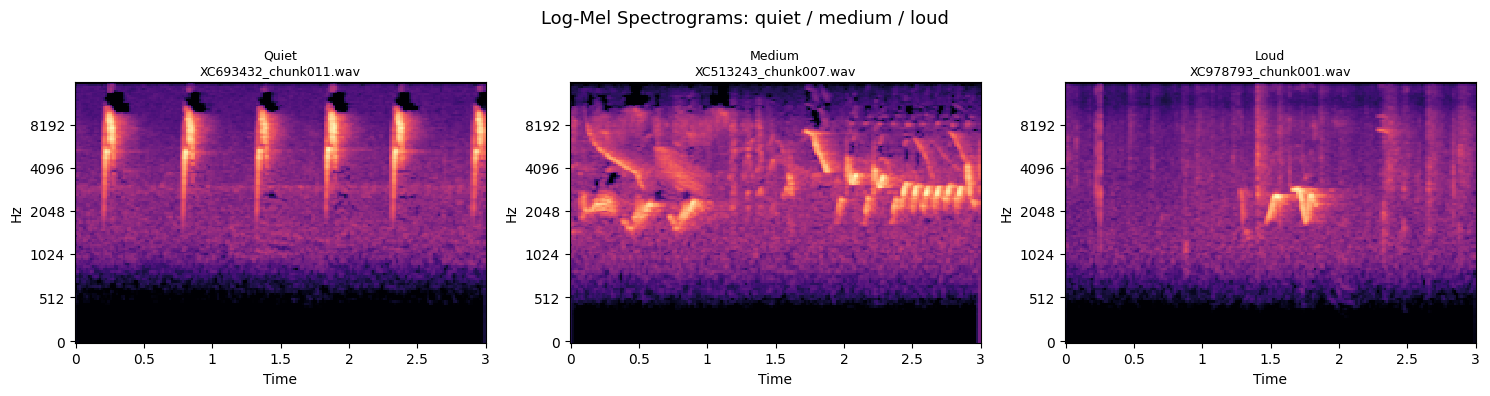

Computing statistics for 150 chunks ...


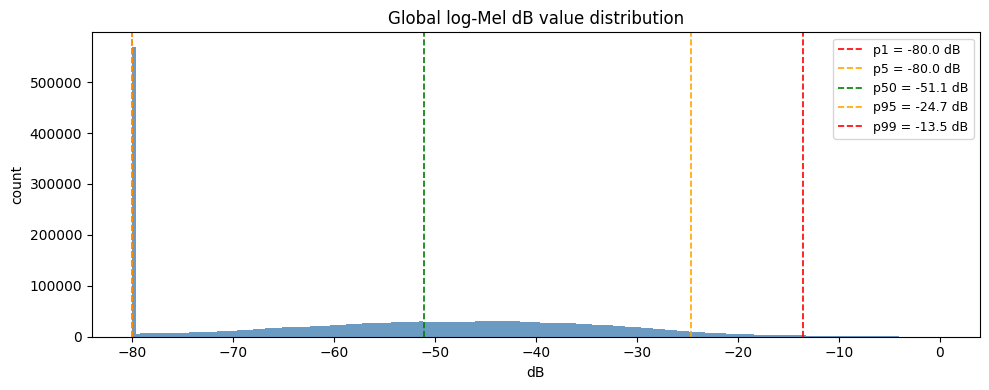

dB percentiles: {'p1': '-80.0', 'p5': '-80.0', 'p50': '-51.1', 'p95': '-24.7', 'p99': '-13.5'}


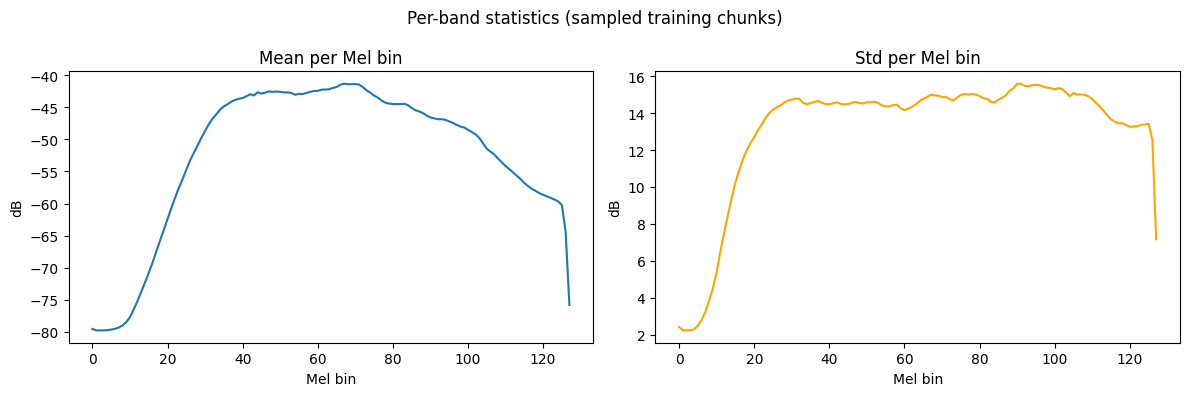

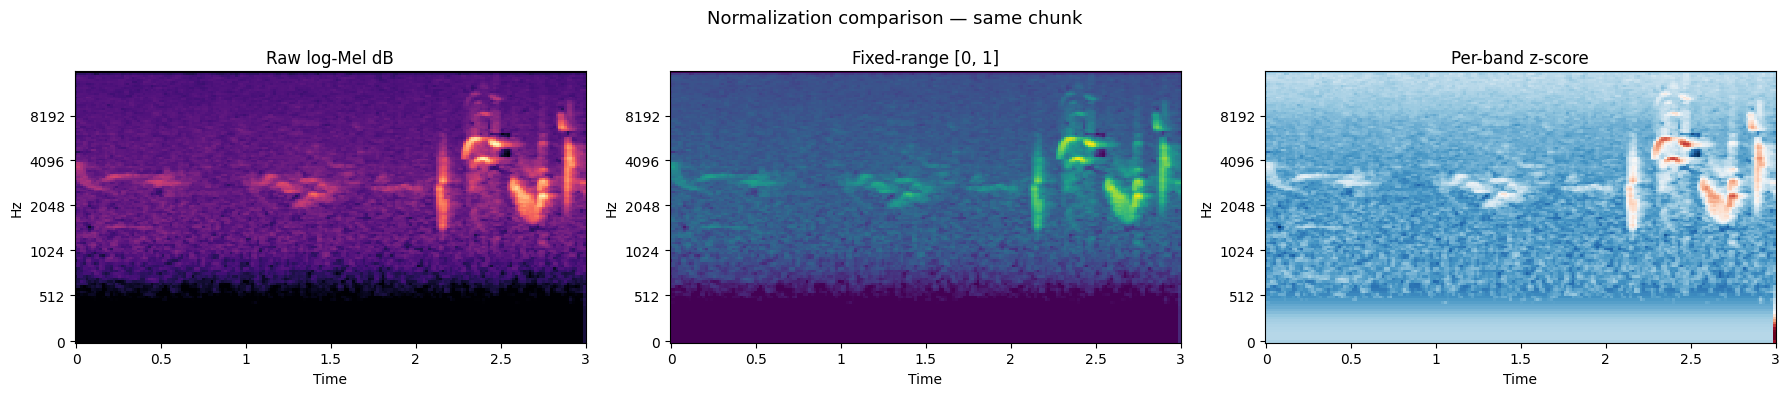

Diagnostic plots saved to /content/processed_audio
Set NORM_METHOD in Step 8 based on the plots above.


In [30]:
import random
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
from pathlib import Path

N_FFT      = 2048
HOP_LENGTH = 512
N_MELS     = 128
SR         = 32_000
DB_MIN     = -80.0
DB_MAX     = 0.0

DIAG_SAMPLE_SIZE = 150
random.seed(42)

all_wav_paths = sorted(PROCESSED_DIR.rglob("*.wav"))
sampled_paths = random.sample(all_wav_paths, min(DIAG_SAMPLE_SIZE, len(all_wav_paths)))
print(f"Sampled {len(sampled_paths)} chunks from {len(all_wav_paths)} total.")


def wav_to_logmel(path):
    audio, _ = librosa.load(str(path), sr=SR, mono=True)
    mel = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    return librosa.power_to_db(mel, ref=np.max)


# ── Plot 1: Spectrogram panels ─────────────────────────────────────────────
panel_dbs = [(p, wav_to_logmel(p)) for p in sampled_paths[:50]]
panel_dbs.sort(key=lambda x: x[1].max())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Log-Mel Spectrograms: quiet / medium / loud", fontsize=13)
for ax, label, item in zip(axes, ["Quiet", "Medium", "Loud"],
        [panel_dbs[0], panel_dbs[len(panel_dbs) // 2], panel_dbs[-1]]):
    path, db = item
    librosa.display.specshow(db, sr=SR, hop_length=HOP_LENGTH,
                             x_axis="time", y_axis="mel", ax=ax,
                             cmap="magma", vmin=DB_MIN, vmax=DB_MAX)
    ax.set_title(f"{label}\n{path.name[:30]}", fontsize=9)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "diag_spectrograms.png"), dpi=120)
plt.show()

# ── Plot 2: Global dB histogram ────────────────────────────────────────────
print(f"Computing statistics for {len(sampled_paths)} chunks ...")
all_dbs = np.concatenate([wav_to_logmel(p).ravel() for p in sampled_paths])
pcts    = np.percentile(all_dbs, [1, 5, 50, 95, 99])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_dbs, bins=200, color="steelblue", alpha=0.8)
for p_val, color, lbl in zip(pcts,
        ["red", "orange", "green", "orange", "red"],
        ["p1", "p5", "p50", "p95", "p99"]):
    ax.axvline(p_val, color=color, linestyle="--", linewidth=1.2,
               label=f"{lbl} = {p_val:.1f} dB")
ax.set_title("Global log-Mel dB value distribution")
ax.set_xlabel("dB")
ax.set_ylabel("count")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "diag_db_histogram.png"), dpi=120)
plt.show()
print("dB percentiles:", {f"p{p}": f"{v:.1f}" for p, v in zip([1, 5, 50, 95, 99], pcts)})

# ── Plot 3: Per-band statistics ────────────────────────────────────────────
mel_stack = np.stack([wav_to_logmel(p) for p in sampled_paths], axis=0)
band_mean = mel_stack.mean(axis=(0, 2))
band_std  = mel_stack.std(axis=(0, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(band_mean)
axes[0].set_title("Mean per Mel bin")
axes[0].set_xlabel("Mel bin")
axes[0].set_ylabel("dB")
axes[1].plot(band_std, color="orange")
axes[1].set_title("Std per Mel bin")
axes[1].set_xlabel("Mel bin")
axes[1].set_ylabel("dB")
fig.suptitle("Per-band statistics (sampled training chunks)")
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "diag_per_band_stats.png"), dpi=120)
plt.show()

# ── Plot 4: Normalization comparison ──────────────────────────────────────
sample_db   = wav_to_logmel(sampled_paths[len(sampled_paths) // 2])
norm_01     = (np.clip(sample_db, DB_MIN, DB_MAX) - DB_MIN) / (DB_MAX - DB_MIN)
norm_zscore = (sample_db - band_mean[:, None]) / (band_std[:, None] + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Normalization comparison — same chunk", fontsize=13)
for ax, data, title, cmap in zip(axes,
        [sample_db, norm_01, norm_zscore],
        ["Raw log-Mel dB", "Fixed-range [0, 1]", "Per-band z-score"],
        ["magma", "viridis", "RdBu_r"]):
    librosa.display.specshow(data, sr=SR, hop_length=HOP_LENGTH,
                             x_axis="time", y_axis="mel", ax=ax, cmap=cmap)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / "diag_normalization_comparison.png"), dpi=120)
plt.show()

print("Diagnostic plots saved to", PROCESSED_DIR)
print("Set NORM_METHOD in Step 8 based on the plots above.")

## Step 7.5 — Chunk Audition

Listen to and inspect individual WAV chunks before committing to tensor export.

- Leave `AUDITION_PATH = None` to pick a **random chunk** each time the cell runs.
- Set `AUDITION_PATH = "path/to/chunk.wav"` to inspect a specific file.

Each run shows the raw waveform, the log-Mel spectrogram, and an inline audio player.


Auditioning: /content/processed_audio/Troglodytes_aedon/XC148175_chunk001.wav
Species    : Troglodytes_aedon


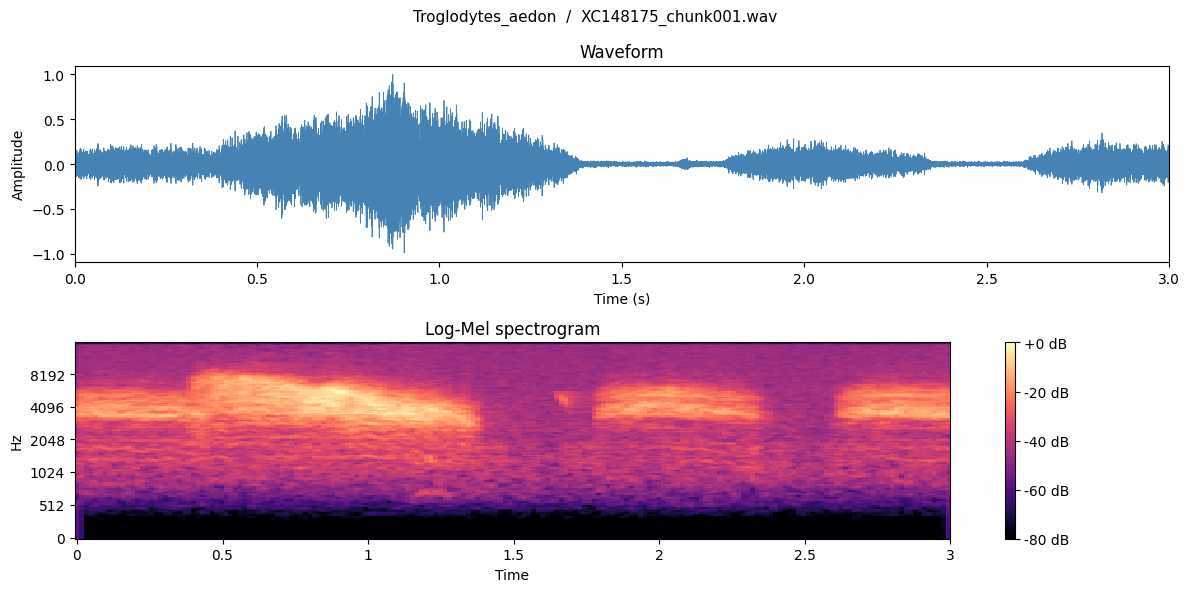

In [57]:
import random
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Audio

N_FFT      = 2048
HOP_LENGTH = 512
N_MELS     = 128
SR         = 32_000
DB_MIN     = -80.0
DB_MAX     = 0.0

# ── Set to None for a random chunk, or provide an explicit path ───────────
# e.g. "/content/processed_audio/Turdus_fuscater/XC12345_chunk001.wav"
AUDITION_PATH = None

# ── Resolve the target file ───────────────────────────────────────────────
if AUDITION_PATH is not None:
    target = Path(AUDITION_PATH)
    if not target.exists():
        raise FileNotFoundError(f"Chunk not found: {target}")
else:
    all_chunks = sorted(PROCESSED_DIR.rglob("*.wav"))
    if not all_chunks:
        raise RuntimeError("No WAV chunks found. Run Step 6 first.")
    target = random.choice(all_chunks)

print(f"Auditioning: {target}")
print(f"Species    : {target.parent.name}")

# ── Load audio ────────────────────────────────────────────────────────────
audio, _ = librosa.load(str(target), sr=SR, mono=True)

# ── Compute log-Mel spectrogram ───────────────────────────────────────────
mel = librosa.feature.melspectrogram(
    y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
)
db = librosa.power_to_db(mel, ref=np.max)

# ── Plot waveform + spectrogram ───────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
fig.suptitle(f"{target.parent.name}  /  {target.name}", fontsize=11)

# Waveform
times = np.linspace(0, len(audio) / SR, num=len(audio))
axes[0].plot(times, audio, linewidth=0.6, color="steelblue")
axes[0].set_title("Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")
axes[0].set_xlim(0, len(audio) / SR)

# Log-Mel spectrogram
librosa.display.specshow(
    db, sr=SR, hop_length=HOP_LENGTH,
    x_axis="time", y_axis="mel",
    ax=axes[1], cmap="magma", vmin=DB_MIN, vmax=DB_MAX
)
axes[1].set_title("Log-Mel spectrogram")
fig.colorbar(axes[1].collections[0], ax=axes[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

# ── Inline audio player ───────────────────────────────────────────────────
display(Audio(data=audio, rate=SR))


## Step 8 — Export Tensors for Training

Convert all processed `.wav` chunks to `(128, 188)` log-Mel spectrogram tensors, apply the chosen normalization, group chunks by species into 3-D NumPy arrays, and serialize each to a compressed `.npz` file in `bird_tensors/` on Drive.

Before conversion, each species is **capped at `MAX_CHUNKS_PER_SPECIES` chunks** (default: 350), selected with a fixed random seed. This keeps class sizes balanced and prevents dominant species from biasing model training.

A `tensor_index.json` is also written containing chunk counts, normalization metadata, the per-species cap, and 5-fold cross-validation assignments.

Set `NORM_METHOD = "fixed_range"` (default) or `"per_band_zscore"` (requires Step 7 to have been run first in the same session).


In [58]:
import json
import random
import numpy as np
import librosa
from pathlib import Path

N_FFT      = 2048
HOP_LENGTH = 512
N_MELS     = 128
SR         = 32_000
DB_MIN     = -80.0
DB_MAX     = 0.0

# ── Choose normalization ──────────────────────────────────────────────────
# "fixed_range"     → clip dB to [DB_MIN, DB_MAX], scale to [0, 1]
# "per_band_zscore" → z-score per Mel bin; requires band_mean / band_std from Step 7
NORM_METHOD = "fixed_range"

TARGET_FRAMES  = 188
MAX_CHUNKS_PER_SPECIES = 350   # cap per species for balanced training
SAMPLE_SEED    = 42

# ── 5-fold cross-validation ───────────────────────────────────────────────
N_FOLDS   = 5
FOLD_SEED = 42

TENSORS_DIR.mkdir(parents=True, exist_ok=True)


def wav_to_tensor(path, norm_params):
    audio, _ = librosa.load(str(path), sr=SR, mono=True)
    mel    = librosa.feature.melspectrogram(
        y=audio, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    db = librosa.power_to_db(mel, ref=np.max)

    if norm_params["method"] == "fixed_range":
        lo, hi = norm_params["db_min"], norm_params["db_max"]
        tensor = (np.clip(db, lo, hi) - lo) / (hi - lo)
    elif norm_params["method"] == "per_band_zscore":
        mean   = np.array(norm_params["band_mean"])[:, None]
        std    = np.array(norm_params["band_std"])[:, None] + 1e-6
        tensor = (db - mean) / std
    else:
        tensor = db

    if tensor.shape[1] < TARGET_FRAMES:
        tensor = np.pad(tensor, ((0, 0), (0, TARGET_FRAMES - tensor.shape[1])))
    else:
        tensor = tensor[:, :TARGET_FRAMES]

    return tensor.astype(np.float32)


if NORM_METHOD == "fixed_range":
    norm_params = {"method": "fixed_range", "db_min": DB_MIN, "db_max": DB_MAX}
elif NORM_METHOD == "per_band_zscore":
    norm_params = {
        "method":    "per_band_zscore",
        "band_mean": band_mean.tolist(),
        "band_std":  band_std.tolist(),
    }
else:
    raise ValueError(f"Unknown NORM_METHOD: {NORM_METHOD!r}")

tensor_index = {
    "norm_method":           norm_params["method"],
    "norm_params":           {k: v for k, v in norm_params.items() if k != "method"},
    "n_folds":               N_FOLDS,
    "fold_seed":             FOLD_SEED,
    "max_chunks_per_species": MAX_CHUNKS_PER_SPECIES,
    "species": {},
}

rng_sample = random.Random(SAMPLE_SEED)

species_dirs = sorted(d for d in PROCESSED_DIR.iterdir() if d.is_dir())
print(f"Exporting tensors for {len(species_dirs)} species "
      f"(cap: {MAX_CHUNKS_PER_SPECIES} chunks each) ...")
total_chunks = 0

for species_dir in species_dirs:
    wav_paths = sorted(species_dir.glob("*.wav"))
    if not wav_paths:
        continue

    # ── Cap to MAX_CHUNKS_PER_SPECIES with reproducible shuffle ───────────
    if len(wav_paths) > MAX_CHUNKS_PER_SPECIES:
        wav_paths = rng_sample.sample(wav_paths, MAX_CHUNKS_PER_SPECIES)
        wav_paths = sorted(wav_paths)   # keep deterministic disk order

    tensors = []
    for wav_path in wav_paths:
        try:
            tensors.append(wav_to_tensor(wav_path, norm_params))
        except Exception as exc:
            print(f"  skip {wav_path.name}: {exc}")

    if not tensors:
        continue

    arr      = np.stack(tensors, axis=0)
    npz_path = TENSORS_DIR / f"{species_dir.name}.npz"
    np.savez_compressed(str(npz_path), spectrograms=arr)

    n            = len(tensors)
    indices      = list(range(n))
    rng_fold     = random.Random(FOLD_SEED)
    rng_fold.shuffle(indices)
    fold_of_chunk = [None] * n
    for rank, original_idx in enumerate(indices):
        fold_of_chunk[original_idx] = rank % N_FOLDS

    tensor_index["species"][species_dir.name] = {
        "chunk_count":      n,
        "npz_file":         npz_path.name,
        "fold_assignments": fold_of_chunk,
    }
    total_chunks += n
    print(f"  {species_dir.name}: {n} chunks → {npz_path.name}")

index_path = TENSORS_DIR / "tensor_index.json"
with open(index_path, "w", encoding="utf-8") as f:
    json.dump(tensor_index, f, ensure_ascii=False, indent=2)

print(f"\nTensors exported to   : {TENSORS_DIR}")
print(f"Tensor index saved at : {index_path}")
print(f"Total species exported: {len(tensor_index['species'])}")
print(f"Total chunks exported : {total_chunks}")


Exporting tensors for 125 species (cap: 350 chunks each) ...
  Acropternis_orthonyx: 350 chunks → Acropternis_orthonyx.npz
  Amazona_farinosa: 350 chunks → Amazona_farinosa.npz
  Andigena_nigrirostris: 350 chunks → Andigena_nigrirostris.npz
  Anisognathus_igniventris: 287 chunks → Anisognathus_igniventris.npz
  Arremon_assimilis: 350 chunks → Arremon_assimilis.npz
  Arremon_brunneinucha: 350 chunks → Arremon_brunneinucha.npz
  Arremonops_conirostris: 350 chunks → Arremonops_conirostris.npz
  Atlapetes_pallidinucha: 350 chunks → Atlapetes_pallidinucha.npz
  Atlapetes_schistaceus: 350 chunks → Atlapetes_schistaceus.npz
  Aulacorhynchus_albivitta: 350 chunks → Aulacorhynchus_albivitta.npz
  Basileuterus_tristriatus: 350 chunks → Basileuterus_tristriatus.npz
  Camptostoma_obsoletum: 322 chunks → Camptostoma_obsoletum.npz
  Cantorchilus_leucotis: 350 chunks → Cantorchilus_leucotis.npz
  Cantorchilus_nigricapillus: 246 chunks → Cantorchilus_nigricapillus.npz
  Capito_auratus: 124 chunks → Ca

## Step 8.5 — Tensor Validation

Three visual checks run directly on the exported `.npz` files — no WAV loading needed:

1. **Class distribution** — horizontal bar chart of chunk counts per species. A healthy dataset has bars of similar length; any species near zero was likely filtered out entirely.
2. **Spectrogram grid** — random tensors drawn from 3 randomly chosen species and displayed as `imshow` heatmaps. Each tile is a `(128, 188)` float32 slice exactly as the model will see it.
3. **Value statistics** — per-file min / max / mean / std and a NaN/Inf check. A pass/fail line is printed for each species.


Normalization  : fixed_range
Species found  : 125
Tensors dir    : /content/bird_tensors



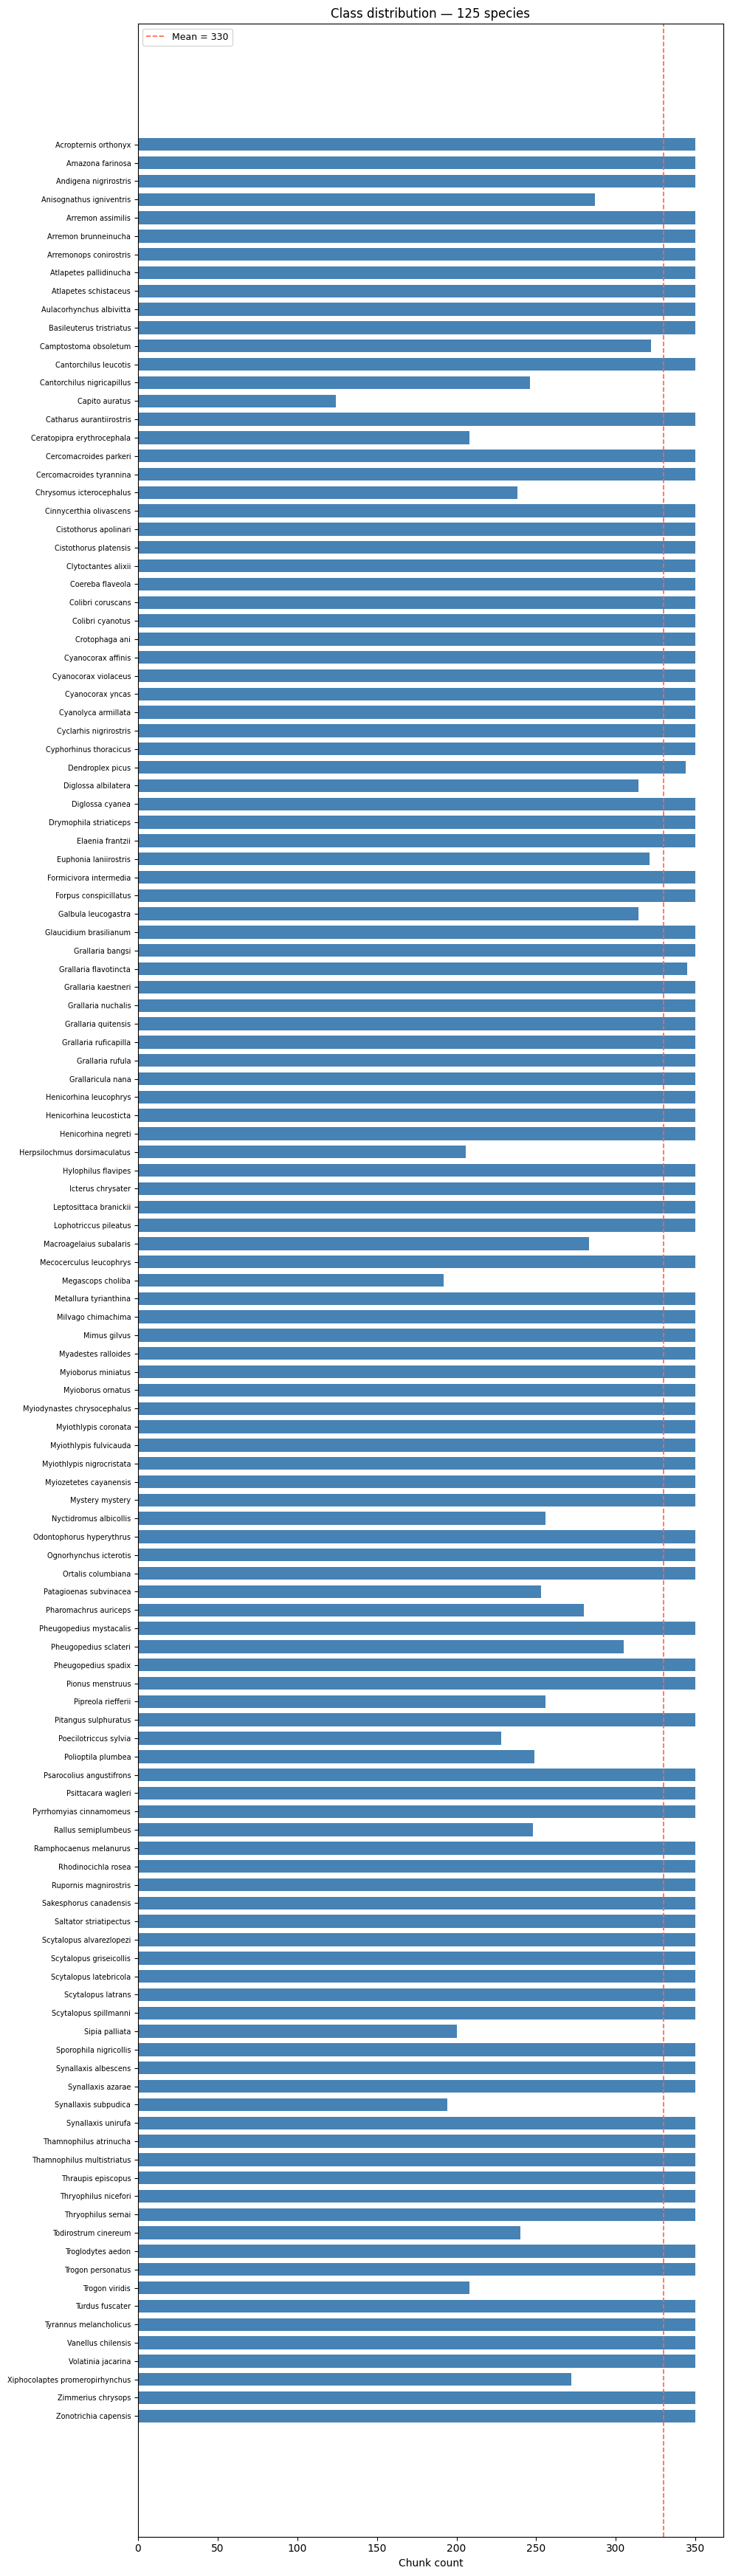

Chunk counts  — min: 124, max: 350, mean: 329.9



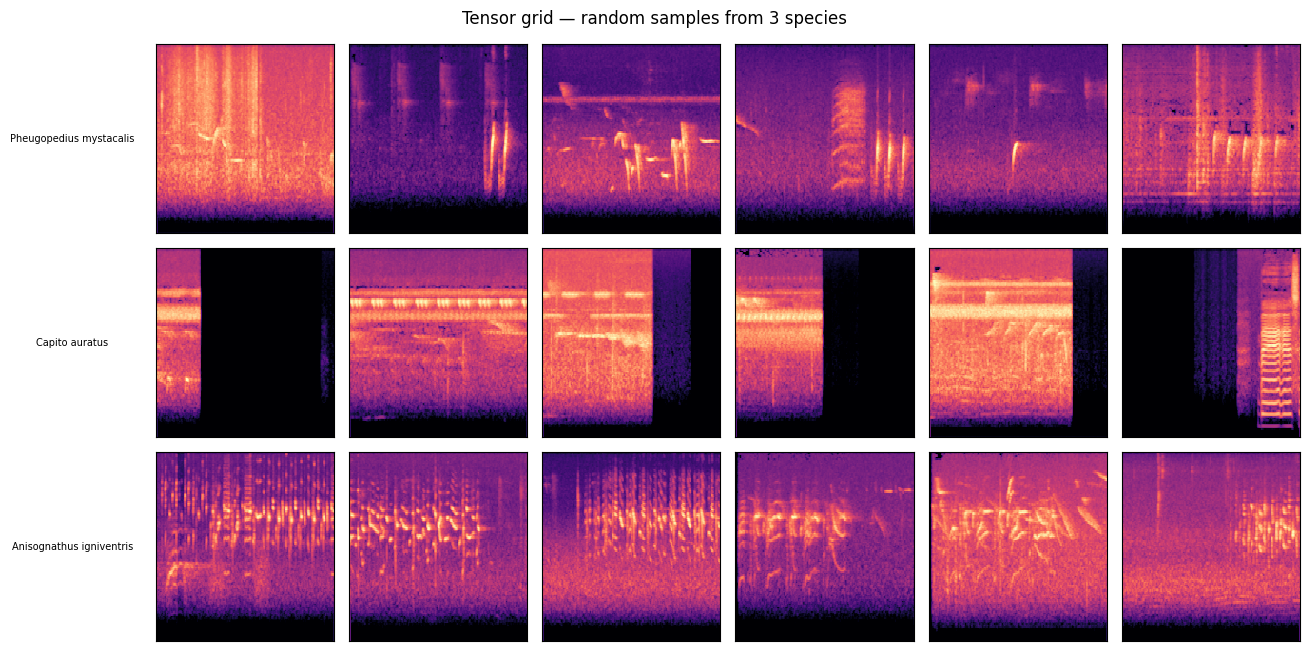

Species                                      N      min      max     mean     std  status
------------------------------------------------------------------------------------------
Acropternis orthonyx                       350    0.000    1.000    0.226   0.176  PASS
Amazona farinosa                           350    0.000    1.000    0.381   0.240  PASS
Andigena nigrirostris                      350    0.000    1.000    0.432   0.220  PASS
Anisognathus igniventris                   287    0.000    1.000    0.421   0.218  PASS
Arremon assimilis                          350    0.000    1.000    0.316   0.191  PASS
Arremon brunneinucha                       350    0.000    1.000    0.369   0.222  PASS
Arremonops conirostris                     350    0.000    1.000    0.317   0.206  PASS
Atlapetes pallidinucha                     350    0.000    1.000    0.380   0.220  PASS
Atlapetes schistaceus                      350    0.000    1.000    0.372   0.220  PASS
Aulacorhynchus albivitta   

In [59]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

VALIDATION_SEED   = 42
GRID_SPECIES      = 3    # species shown in the spectrogram grid
GRID_TILES_EACH   = 6    # tensors per species in the grid

random.seed(VALIDATION_SEED)

index_path = TENSORS_DIR / "tensor_index.json"
if not index_path.exists():
    raise FileNotFoundError("tensor_index.json not found. Run Step 8 first.")

with open(index_path, "r", encoding="utf-8") as fh:
    tensor_index = json.load(fh)

norm_method  = tensor_index.get("norm_method", "unknown")
species_meta = tensor_index.get("species", {})
all_species  = sorted(species_meta.keys())

print(f"Normalization  : {norm_method}")
print(f"Species found  : {len(all_species)}")
print(f"Tensors dir    : {TENSORS_DIR}\n")


# ══════════════════════════════════════════════════════════════════════════
# Plot 1 — Class distribution bar chart
# ══════════════════════════════════════════════════════════════════════════
counts  = [species_meta[s]["chunk_count"] for s in all_species]
y_pos   = range(len(all_species))
labels  = [s.replace("_", " ") for s in all_species]

fig_h   = max(6, len(all_species) * 0.28)
fig, ax = plt.subplots(figsize=(10, fig_h))

bars = ax.barh(list(y_pos), counts, color="steelblue", edgecolor="none", height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("Chunk count")
ax.set_title(f"Class distribution — {len(all_species)} species", fontsize=12)
ax.axvline(np.mean(counts), color="tomato", linestyle="--", linewidth=1.2,
           label=f"Mean = {np.mean(counts):.0f}")
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(str(TENSORS_DIR / "val_class_distribution.png"), dpi=120)
plt.show()
print(f"Chunk counts  — min: {min(counts)}, max: {max(counts)}, mean: {np.mean(counts):.1f}\n")


# ══════════════════════════════════════════════════════════════════════════
# Plot 2 — Spectrogram grid (raw tensor values, no audio reload)
# ══════════════════════════════════════════════════════════════════════════
grid_species = random.sample(all_species, min(GRID_SPECIES, len(all_species)))

# Determine colour limits from normalization type
if norm_method == "fixed_range":
    vmin, vmax, cmap = 0.0, 1.0, "magma"
else:
    vmin, vmax, cmap = -3.0, 3.0, "RdBu_r"

n_cols  = GRID_TILES_EACH
n_rows  = len(grid_species)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 2.2, n_rows * 2.2),
                         squeeze=False)
fig.suptitle("Tensor grid — random samples from 3 species", fontsize=12)

for row, sp_name in enumerate(grid_species):
    npz_path = TENSORS_DIR / species_meta[sp_name]["npz_file"]
    data     = np.load(str(npz_path))["spectrograms"]   # (N, 128, 188)
    n        = data.shape[0]
    indices  = random.sample(range(n), min(n_cols, n))

    for col in range(n_cols):
        ax = axes[row][col]
        if col < len(indices):
            ax.imshow(data[indices[col]], aspect="auto", origin="lower",
                      cmap=cmap, vmin=vmin, vmax=vmax,
                      interpolation="nearest")
            if col == 0:
                ax.set_ylabel(sp_name.replace("_", " "), fontsize=7,
                              rotation=0, labelpad=60, va="center")
        else:
            ax.axis("off")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig(str(TENSORS_DIR / "val_tensor_grid.png"), dpi=120)
plt.show()


# ══════════════════════════════════════════════════════════════════════════
# Plot 3 — Per-species value statistics (text report + pass/fail)
# ══════════════════════════════════════════════════════════════════════════
print(f"{'Species':<40} {'N':>5}  {'min':>7}  {'max':>7}  {'mean':>7}  {'std':>6}  status")
print("-" * 90)

n_pass = n_fail = 0
for sp_name in all_species:
    npz_path = TENSORS_DIR / species_meta[sp_name]["npz_file"]
    data     = np.load(str(npz_path))["spectrograms"].astype(np.float32)

    has_nan  = bool(np.isnan(data).any())
    has_inf  = bool(np.isinf(data).any())
    ok       = not has_nan and not has_inf

    issues = []
    if has_nan:
        issues.append("NaN")
    if has_inf:
        issues.append("Inf")

    status = "PASS" if ok else f"FAIL ({', '.join(issues)})"
    if ok:
        n_pass += 1
    else:
        n_fail += 1

    label = sp_name.replace("_", " ")[:39]
    print(f"{label:<40} {data.shape[0]:>5}  {data.min():>7.3f}  {data.max():>7.3f}"
          f"  {data.mean():>7.3f}  {data.std():>6.3f}  {status}")

print("-" * 90)
print(f"Result: {n_pass} PASS  |  {n_fail} FAIL")


## Step 9 — Fold Split Materialization

Reads the per-species tensors and fold assignments produced by Step 8 and assembles them into **5 ready-to-train split pairs** saved to `bird_splits/`.

For split `k` (0–4):
- `split_k_train.npz` — all chunks **not** in fold `k` (~80 % of the dataset)
- `split_k_val.npz`   — all chunks in fold `k` (~20 % of the dataset)

Each `.npz` contains two arrays:

| Array | Shape | Dtype | Description |
|-------|-------|-------|-------------|
| `spectrograms` | `(M, 128, 188)` | `float32` | Log-Mel tensors normalised as in Step 8 |
| `labels` | `(M,)` | `int32` | Integer class index per chunk |

A `label_map.json` (integer → species name, alphabetically sorted) and a `splits_summary.json` (per-split chunk counts and val %) are also written to `bird_splits/`.

> `SPLITS_DIR` is defined here and reused by Step 10. Run after Step 8.


In [ ]:
import json
import numpy as np
from pathlib import Path

SPLITS_DIR = OUTPUT_BASE / "bird_splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

# ── Load tensor index ─────────────────────────────────────────────────────
index_path = TENSORS_DIR / "tensor_index.json"
if not index_path.exists():
    raise FileNotFoundError("tensor_index.json not found. Run Step 8 first.")

with open(index_path, "r", encoding="utf-8") as fh:
    tensor_index = json.load(fh)

species_meta = tensor_index.get("species", {})
n_folds      = tensor_index.get("n_folds", 5)
all_species  = sorted(species_meta.keys())   # alphabetical → deterministic labels

if not all_species:
    raise RuntimeError("No species found in tensor_index.json.")

# ── Build integer label map (0 … N-1, alphabetically sorted) ─────────────
label_map     = {i: name for i, name in enumerate(all_species)}   # int → species
label_map_inv = {v: k for k, v in label_map.items()}              # species → int

label_map_path = SPLITS_DIR / "label_map.json"
with open(label_map_path, "w", encoding="utf-8") as fh:
    json.dump(label_map, fh, ensure_ascii=False, indent=2)

print(f"Label map saved : {label_map_path}  ({len(label_map)} classes)")

# ── Accumulate chunks per fold across all species ─────────────────────────
fold_spectrograms = [[] for _ in range(n_folds)]
fold_labels       = [[] for _ in range(n_folds)]

print(f"\nLoading tensors for {len(all_species)} species ...")

for sp_name in all_species:
    meta     = species_meta[sp_name]
    npz_path = TENSORS_DIR / meta["npz_file"]

    if not npz_path.exists():
        print(f"  WARNING: {npz_path.name} not found — skipping {sp_name}")
        continue

    data             = np.load(str(npz_path))["spectrograms"]   # (N, 128, 188) float32
    fold_assignments = meta["fold_assignments"]                  # list length N, values 0–4
    label_idx        = label_map_inv[sp_name]

    for chunk_idx, fold_id in enumerate(fold_assignments):
        fold_spectrograms[fold_id].append(data[chunk_idx])
        fold_labels[fold_id].append(label_idx)

fold_sizes   = [len(fold_labels[k]) for k in range(n_folds)]
total_chunks = sum(fold_sizes)

print(f"Total chunks across all species : {total_chunks:,}")
print(f"Per-fold chunk counts           : {fold_sizes}")

# ── Build and save 5 train/val split pairs ────────────────────────────────
splits_summary = {
    "total_chunks": total_chunks,
    "n_folds":      n_folds,
    "label_map":    label_map,
    "splits":       {},
}

print(f"\nWriting {n_folds} split pairs to {SPLITS_DIR} ...")
print(f"\n{'Split':<8} {'Train':>8} {'Val':>8} {'Val %':>7}")
print("-" * 36)

for k in range(n_folds):
    # Val  = fold k  (~20 %)
    val_specs  = np.stack(fold_spectrograms[k], axis=0).astype(np.float32)
    val_labels = np.array(fold_labels[k], dtype=np.int32)

    # Train = all other folds  (~80 %)
    train_specs = np.concatenate(
        [np.stack(fold_spectrograms[j], axis=0) for j in range(n_folds) if j != k],
        axis=0,
    ).astype(np.float32)
    train_labels = np.concatenate(
        [np.array(fold_labels[j], dtype=np.int32) for j in range(n_folds) if j != k],
        axis=0,
    )

    train_path = SPLITS_DIR / f"split_{k}_train.npz"
    val_path   = SPLITS_DIR / f"split_{k}_val.npz"

    np.savez_compressed(str(train_path), spectrograms=train_specs, labels=train_labels)
    np.savez_compressed(str(val_path),   spectrograms=val_specs,   labels=val_labels)

    val_pct = 100.0 * len(val_labels) / total_chunks
    print(f"split_{k}   {len(train_labels):>8,}  {len(val_labels):>8,}  {val_pct:>6.1f}%")

    splits_summary["splits"][f"split_{k}"] = {
        "train_chunks": int(len(train_labels)),
        "val_chunks":   int(len(val_labels)),
        "val_percent":  round(val_pct, 2),
        "train_file":   train_path.name,
        "val_file":     val_path.name,
    }

print("-" * 36)

summary_path = SPLITS_DIR / "splits_summary.json"
with open(summary_path, "w", encoding="utf-8") as fh:
    json.dump(splits_summary, fh, ensure_ascii=False, indent=2)

print(f"\nSplits summary saved : {summary_path}")
print(f"All split files in   : {SPLITS_DIR}")


## Step 10 — Archive & Save to Google Drive

Compresses the entire `bird_splits/` folder into a single `.zip` archive (DEFLATED) and saves it to Google Drive under `MyDrive/bird_splits_archive/`.

- If `USE_DRIVE = True` was set in Step 2, the splits are already on Drive. The archive is still created there for easy single-file download.
- If `USE_DRIVE = False`, the splits are on the local Colab disk. Drive is mounted in this step and the archive is written directly there — ensuring the splits **survive the session**.

The archive filename includes a timestamp: `bird_splits_YYYYMMDD_HHMMSS.zip`.

> Run after Step 9. Only the `bird_splits/` folder is archived; raw MP3s, WAV chunks, and per-species tensors are not included.


In [ ]:
import zipfile
from datetime import datetime
from pathlib import Path

# ── SPLITS_DIR is defined in Step 9 ──────────────────────────────────────
# If running this step standalone after a kernel restart, uncomment:
# SPLITS_DIR = OUTPUT_BASE / "bird_splits"

# ── Mount Drive if not already mounted ───────────────────────────────────
DRIVE_ARCHIVE_DIR = Path("/content/drive/MyDrive/bird_splits_archive")

drive_mounted = Path("/content/drive/MyDrive").exists()
if not drive_mounted:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

DRIVE_ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Validate source ───────────────────────────────────────────────────────
if not SPLITS_DIR.exists() or not any(SPLITS_DIR.iterdir()):
    raise RuntimeError(f"No split files found in {SPLITS_DIR}. Run Step 9 first.")

# ── Build timestamped archive path ────────────────────────────────────────
timestamp    = datetime.now().strftime("%Y%m%d_%H%M%S")
archive_name = f"bird_splits_{timestamp}.zip"
archive_path = DRIVE_ARCHIVE_DIR / archive_name

# ── Collect files ─────────────────────────────────────────────────────────
files_to_pack = [f for f in SPLITS_DIR.rglob("*") if f.is_file()]
print(f"Packing {len(files_to_pack)} files from {SPLITS_DIR} ...")

# ── Create .zip archive (DEFLATED compression) ────────────────────────────
with zipfile.ZipFile(str(archive_path), "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in files_to_pack:
        arcname = Path("bird_splits") / file_path.relative_to(SPLITS_DIR)
        zf.write(str(file_path), arcname=str(arcname))

archive_size_mb = archive_path.stat().st_size / (1024 ** 2)

print(f"\nArchive created successfully")
print(f"  Path      : {archive_path}")
print(f"  Size      : {archive_size_mb:.1f} MB")
print(f"  Files     : {len(files_to_pack)}")
print(f"\nTo restore on a new session:")
print(f"  import zipfile")
print(f"  with zipfile.ZipFile('{archive_path}', 'r') as zf:")
print(f"      zf.extractall('/content')")


Google Drive already mounted.
Packing 128 files from /content/bird_tensors ...

Archive created successfully
  Path      : /content/drive/MyDrive/bird_tensors_archive/bird_tensors_20260511_005535.zip
  Size      : 2795.3 MB
  Files     : 128

To restore on a new session:
  import zipfile
  with zipfile.ZipFile('/content/drive/MyDrive/bird_tensors_archive/bird_tensors_20260511_005535.zip', 'r') as zf:
      zf.extractall('/content')
